## Pulling in DSSTOX chems

In [1]:
# Use SQLAlchemy to collect chemical data from an old DSSTOX
import sqlalchemy
from sqlalchemy import create_engine
from sqlalchemy.ext.automap import automap_base
from sqlalchemy.orm import Session

In [2]:
from config import username, passwordword
username = "username"
passwordword = "password"
database_path = "ccte-mysql-res.epa.gov"
engine = create_engine(f"mysql+mysqlconnector://{username}:{passwordword}@{database_path}/prod_dsstox")
conn = engine.connect()

In [3]:
Base = automap_base()
Base.prepare(autoload_with=engine)

In [4]:
chems = Base.metadata.tables['dsstox_names']

In [5]:
session = Session(engine)

In [6]:
import pandas as pd
first_df = pd.read_sql_query("SELECT dtxsid FROM dsstox_names ORDER BY RAND() LIMIT 2000 ", engine)


In [7]:
second_df = pd.read_sql_query("SELECT dtxsid FROM dsstox_names ORDER BY RAND() LIMIT 2000 ", engine)

In [8]:
session.rollback()
session.close()

In [9]:
fingerprint_df = pd.concat([first_df, second_df], axis = 0)

In [119]:
fingerprint_df.to_csv('../src/data/fingerprint_analysis.csv')

In [16]:
import pandas as pd
fingerprint_df = pd.read_csv(f"../src/data/print_analysis_2_pre-grid-search.csv")

fingerprint_df = fingerprint_df.dropna()

## Start updated Tests using LD50

In [1]:
import pandas as pd
data = pd.read_csv(f"../src/data/LD50_pre-grid-search_and_TEST.csv")

In [2]:
from sklearn.metrics import pairwise_distances
import numpy as np

slices = [slice(0,729),slice(729,2777), slice(2777,4825), slice(4825, 5727), slice(5727, None)]

tp_dist_matrix = pairwise_distances(np.array(data.iloc[:,slices[0]]), np.array(data.iloc[:,slices[0]]), metric = 'jaccard')
mor_dist_matrix = pairwise_distances(np.array(data.iloc[:,slices[1]]), np.array(data.iloc[:,slices[1]]), metric = 'jaccard')
tor_dist_matrix = pairwise_distances(np.array(data.iloc[:,slices[2]]), np.array(data.iloc[:,slices[2]]), metric = 'jaccard')
aim_dist_matrix = pairwise_distances(np.array(data.iloc[:,slices[3]]), np.array(data.iloc[:,slices[3]]), metric = 'jaccard')
test_dist_matrix = pairwise_distances(np.array(data.iloc[:,slices[4]]), np.array(data.iloc[:,slices[4]]), metric = 'jaccard')

c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybrid\venv\Lib\site-packages\sklearn\metrics\pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybrid\venv\Lib\site-packages\sklearn\metrics\pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybrid\venv\Lib\site-packages\sklearn\metrics\pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybr

In [5]:
hybrids = [
(50*mor_dist_matrix+50*tor_dist_matrix)/100,
(50*mor_dist_matrix + 50*aim_dist_matrix)/100,
(50*mor_dist_matrix + 50*tp_dist_matrix)/100,
(50*tor_dist_matrix + 50*aim_dist_matrix)/100,
(50*tor_dist_matrix + 50*tp_dist_matrix)/100,
(50*aim_dist_matrix + 50*tp_dist_matrix)/100
]

In [7]:
tp_coords = []
mor_coords = []
hybrid_coords = {}
for i in range(6):
    hybrid_coords[i] = []
tor_coords = []
aim_coords = []
test_coords = []
plottable_tp_points = pd.DataFrame(tp_dist_matrix)
plottable_mor_points = pd.DataFrame(mor_dist_matrix)
plottable_hybrid_points = {}
for i in range(6):
    plottable_hybrid_points[i] = pd.DataFrame(hybrids[i])
plottable_tor_points = pd.DataFrame(tor_dist_matrix)
plottable_aim_points = pd.DataFrame(aim_dist_matrix)
plottable_test_points = pd.DataFrame(test_dist_matrix)
for i in range(5830):
    for j in range(5830):
        if i>j:
            tp_coords.append(plottable_tp_points.iloc[i,j])
            mor_coords.append(plottable_mor_points.iloc[i,j])
            for k in range(6):
                hybrid_coords[k].append(plottable_hybrid_points[k].iloc[i,j])
            tor_coords.append(plottable_tor_points.iloc[i,j])
            aim_coords.append(plottable_aim_points.iloc[i,j])
            test_coords.append(plottable_test_points.iloc[i,j])


In [8]:
counters = {}
for low, high in [(k,k+0.1) for k in np.arange(0,1.1,0.1)]:
    counters[f'[{round(low,1)},{round(high,1)})'] = 0 
    for i in range(len(mor_coords)):
        if mor_coords[i]< high and mor_coords[i] >= low:
            counters[f'[{round(low,1)},{round(high,1)})'] += 1

counters

{'[0.0,0.1)': 225,
 '[0.1,0.2)': 108,
 '[0.2,0.3)': 371,
 '[0.3,0.4)': 939,
 '[0.4,0.5)': 2458,
 '[0.5,0.6)': 7486,
 '[0.6,0.7)': 27470,
 '[0.7,0.8)': 166206,
 '[0.8,0.9)': 2798732,
 '[0.9,1.0)': 12619575,
 '[1.0,1.1)': 1367386}

In [9]:
indices = {}
for low, high in [(k,k+0.1) for k in np.arange(0,1.1,0.1)]:
    indices[f'[{round(low,1)},{round(high,1)})'] = []
    for i in range(len(mor_coords)):
        if mor_coords[i]< high and mor_coords[i] >= low:
            indices[f'[{round(low,1)},{round(high,1)})'].append(i)

In [10]:
import random

test_indices = []
for key in indices.keys():
    rand_list = [random.randint(0, len(indices[key])-1) for _ in range(108)]
    for j in rand_list:
        test_indices.append(indices[key][j])


In [26]:
tp_test_values = [tp_coords[x] for x in test_indices]
mor_test_values = [mor_coords[x] for x in test_indices]
tor_test_values = [tor_coords[x] for x in test_indices]
aim_test_values = [aim_coords[x] for x in test_indices]
test_test_values = [test_coords[x] for x in test_indices]
hybrid_test_values = {}
for i in range(6):
    hybrid_test_values[i] = [hybrid_coords[i][x] for x in test_indices]

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import numpy as np

def printPlots(print1, print2, print1_name, print2_name):
    # plt.scatter(print1, print2)
    m,b = np.polyfit(print1, print2, deg = 1)
    print(r2_score(print2, m*np.array(print1)+b))
    # plt.xlabel(f'{print1_name} Distance')
    # plt.ylabel(f'{print2_name} Distance')
    # plt.show()
    return r2_score(print2, m*np.array(print1)+b)

In [38]:
#Set up tests for all necessary combinations
print_tests = {}

print_tests[0] = [mor_test_values, tor_test_values]
print_tests[1] = [mor_test_values, aim_test_values]
print_tests[2] = [mor_test_values, tp_test_values]
print_tests[3] = [tor_test_values, aim_test_values]
print_tests[4] = [tor_test_values, tp_test_values]
print_tests[5] = [aim_test_values, tp_test_values]
for i in range(6):
    print_tests[6+i] = [hybrid_test_values[i]]
for i in range(3):
    print_tests[6+i].append(mor_test_values)
for i in range(2):
    print_tests[9+i].append(tor_test_values)
print_tests[11].append(aim_test_values)

In [110]:
#Obtain the results matrix
results = []
for i in range(12):
    test_info = print_tests[i]
    results.append(printPlots(test_info[0], test_info[1], 'Default', 'Default'))
for i in range(3):
    results.append(1)

results = np.array(results)

0.8640935698229394
0.8204043155024303
0.7983414294992305
0.7356696647662011
0.7470201956202971
0.8280878597435706
0.9609903446413585
0.9472182349298731
0.948395379702077
0.9280047081153455
0.9410897530122287
0.9614183723182242


In [111]:
#Rows represent M,A,T,X,MA,MT,MX,AT,AX,TX,MAT,MAX,MTX,ATX,MATX
#Creates binary representation of the composition of prints leading to each similarity score
rows = {}
rows[1] = [1,0,1,0,0,1,0,0,0,0,1,0,1,0,1]
rows[2] = [1,1,0,0,1,0,0,0,0,0,1,1,0,0,1]
rows[3] = [1,0,0,1,0,0,1,0,0,0,0,1,1,0,1]
rows[4] = [0,1,1,0,0,0,0,1,0,0,1,0,0,1,1]
rows[5] = [0,0,1,1,0,0,0,0,0,1,0,0,1,1,1]
rows[6] = [0,1,0,1,0,0,0,0,1,0,0,1,0,1,1]
rows[7] = [0.5,0,0,0,0.5,1,0.5,0,0,0,1,0.5,1,0,1]
rows[8] = [0.5,0,0,0,1,0.5,0.5,0,0,0,1,1,0.5,0,1]
rows[9] = [0.5,0,0,0,0.5,0.5,1,0,0,0,0.5,1,1,0,1]
rows[10] = [0,0.5,0,0,0.5,0,1,0,0.5,1,0,0,0.5,1,1]
rows[11] = [0,0,0.5,0,0,0.5,0,0.5,0,1,0.5,0,1,1,1]
rows[12] = [0,0.5,0,0,0.5,0,0,0.5,1,0,0.5,1,0,1,1]
rows[13] = [1,0,0,0,1,1,1,0,0,0,1,1,1,0,1]
rows[14] = [0,1,0,0,1,0,0,1,1,0,1,1,0,1,1]
rows[15] = [0,0,1,0,0,1,0,1,0,1,1,0,1,1,1]


big_matrix = np.array([rows[i] for i in range(1,16)])

In [112]:
inverse_matrix = np.linalg.inv(big_matrix)
values = np.matmul(inverse_matrix, results)
values

array([ 4.09427732e+00, -1.45466420e+00, -1.56924293e+00, -1.86628824e+00,
       -3.39604201e+14, -3.39604201e+14,  1.69802100e+14, -3.39604201e+14,
        1.69802100e+14,  1.69802100e+14,  6.79208401e+14,  1.69802100e+14,
        1.69802100e+14,  1.69802100e+14, -5.09406301e+14])

In [84]:
results = [85,80,70,100,100,100,92]
matrix = np.array([
    [0,1,0,0,1,0,0],
    [0,0,0,1,1,0,0],
    [0,0,0,0,1,1,0],
    [1,1,0,1,1,0,0],
    [0,1,1,0,1,1,0],
    [0,0,0,1,1,1,1],
    [0.5,1,0,0.5,1,0.5,0]])
np.matmul(np.linalg.inv(matrix), results)

array([ 6., 14., 16.,  9., 71., -1., 21.])

0.9518913996160863


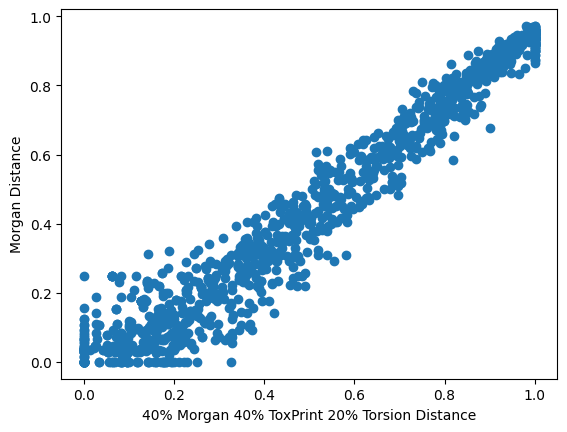

0.9518913996160863

In [36]:
printPlots(hybrid_test_values[1], hybrid_test_values[5], '40% Morgan 40% ToxPrint 20% Torsion', 'Morgan')

0.8594771992828436


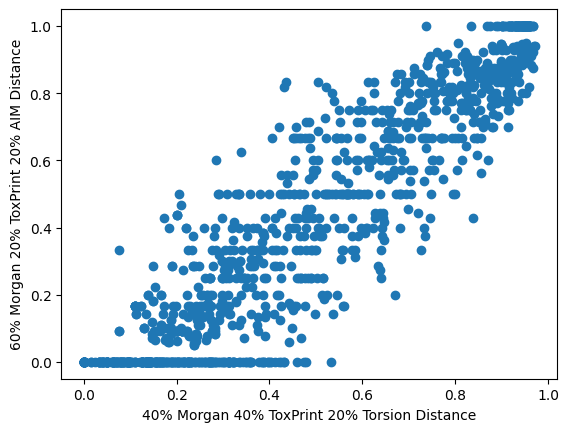

In [11]:
printPlots(hyb2_test_values, aim_test_values, '40% Morgan 40% ToxPrint 20% Torsion', '60% Morgan 20% ToxPrint 20% AIM')

0.7753491850367097


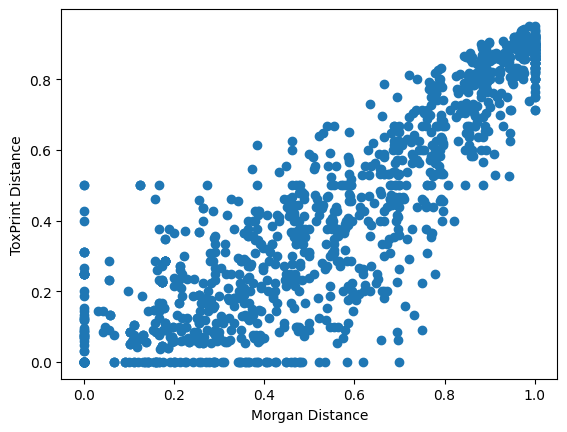

In [97]:
printPlots(mor_test_values, tp_test_values, 'Morgan', "ToxPrint")

0.8637497489758251


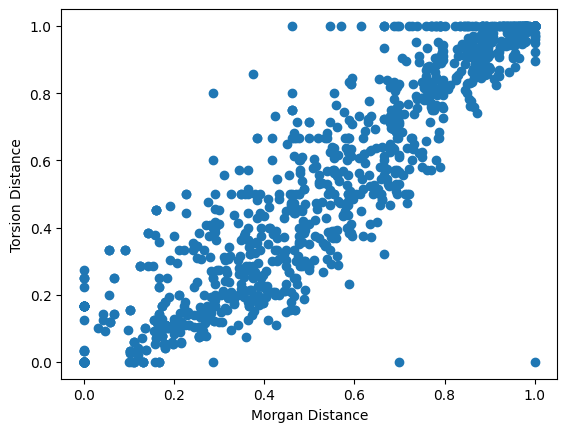

In [99]:
printPlots(mor_test_values, tor_test_values, "Morgan", "Torsion")

0.812724988195518


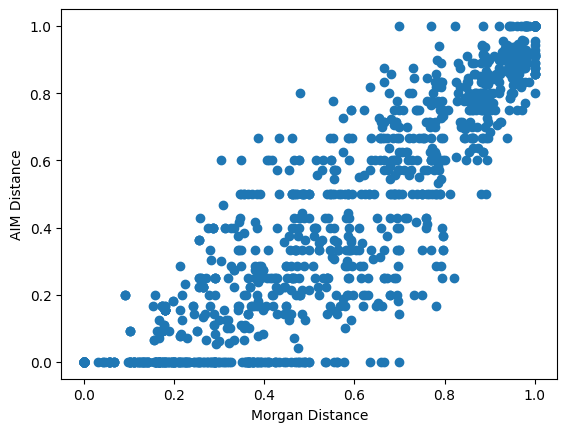

In [100]:
printPlots(mor_test_values, aim_test_values, "Morgan", "AIM")

0.6720439040561919


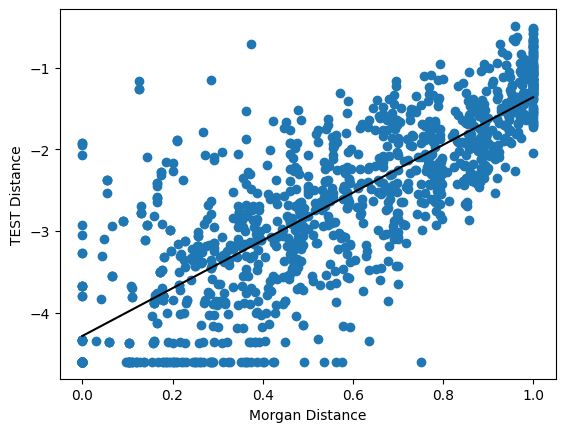

In [118]:
plt.scatter(mor_test_values, np.log(np.array(test_test_values)+0.01))
a,b = np.polyfit(mor_test_values, np.log(np.array(test_test_values)+0.01), deg = 1)
plt.plot(mor_test_values, a*np.array(mor_test_values)+b , color = 'black')
print(r2_score(np.log(np.array(test_test_values)+0.01), a*np.array(mor_test_values)+b))
plt.xlabel(f'Morgan Distance')
plt.ylabel(f'TEST Distance')
plt.show()

0.7324355108044113


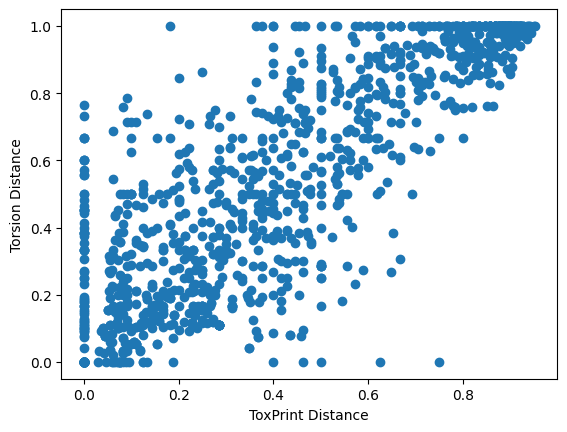

In [103]:
printPlots(tp_test_values, tor_test_values, "ToxPrint", 'Torsion')

0.8175365213713572


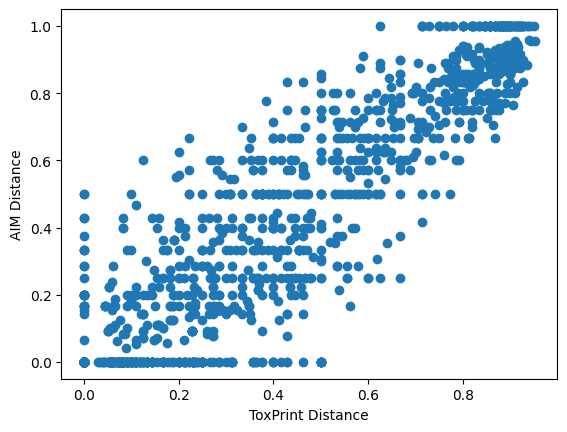

In [104]:
printPlots(tp_test_values, aim_test_values, "ToxPrint", 'AIM')

0.6512889431975628


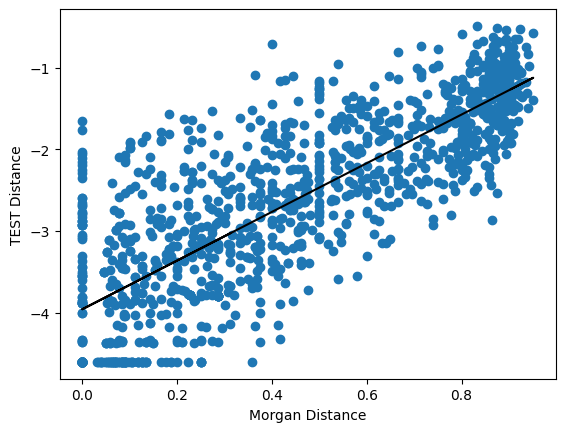

In [119]:
plt.scatter(tp_test_values, np.log(np.array(test_test_values)+0.01))
a,b = np.polyfit(tp_test_values, np.log(np.array(test_test_values)+0.01), deg = 1)
plt.plot(tp_test_values, a*np.array(tp_test_values)+b , color = 'black')
print(r2_score(np.log(np.array(test_test_values)+0.01), a*np.array(tp_test_values)+b))
plt.xlabel(f'ToxPrint Distance')
plt.ylabel(f'TEST Distance')
plt.show()

0.7199574875685288


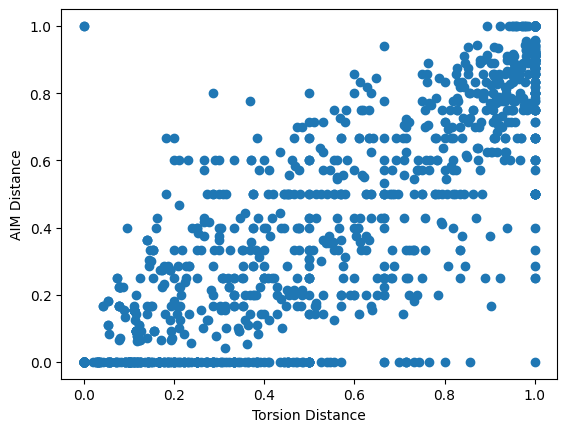

In [120]:
printPlots(tor_test_values, aim_test_values, "Torsion", "AIM")

0.6745939171609829


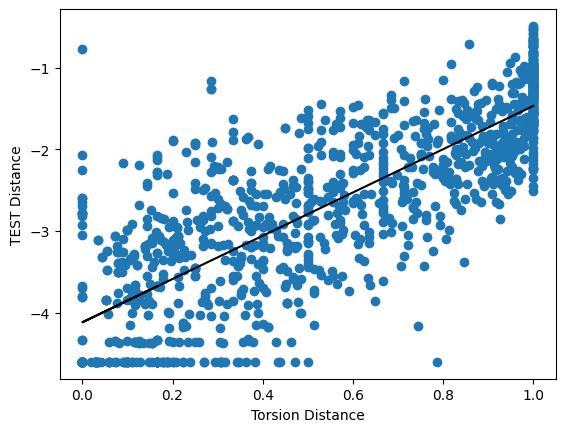

In [123]:
plt.scatter(tor_test_values, np.log(np.array(test_test_values)+0.01))
a,b = np.polyfit(tor_test_values, np.log(np.array(test_test_values)+0.01), deg = 1)
plt.plot(tor_test_values, a*np.array(tor_test_values)+b , color = 'black')
print(r2_score(np.log(np.array(test_test_values)+0.01), a*np.array(tor_test_values)+b))
plt.xlabel(f'Torsion Distance')
plt.ylabel(f'TEST Distance')
plt.show()

0.6362713373898236


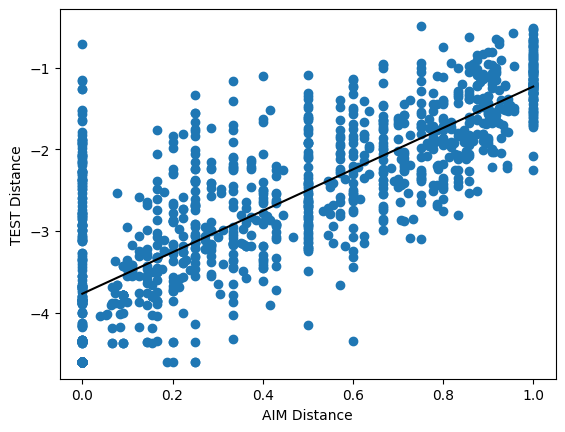

In [124]:
plt.scatter(aim_test_values, np.log(np.array(test_test_values)+0.01))
a,b = np.polyfit(aim_test_values, np.log(np.array(test_test_values)+0.01), deg = 1)
plt.plot(aim_test_values, a*np.array(aim_test_values)+b , color = 'black')
print(r2_score(np.log(np.array(test_test_values)+0.01), a*np.array(aim_test_values)+b))
plt.xlabel(f'AIM Distance')
plt.ylabel(f'TEST Distance')
plt.show()

0.3830314279926633


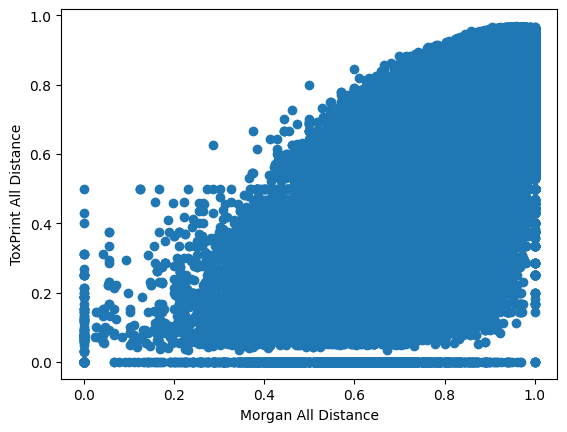

In [125]:
printPlots(mor_coords, tp_coords, 'Morgan All', "ToxPrint All")

## End updated LD50 Tests

In [121]:
from sklearn.metrics import pairwise_distances
import numpy as np

end = int(len(fingerprint_df)/2)

slices = [slice(0,729),slice(729,2777), slice(2777,4825), slice(4825, 5727), slice(5727, None)]

tp_dist_matrix = pairwise_distances(np.array(fingerprint_df.iloc[:end,slices[0]]), np.array(fingerprint_df.iloc[end:,slices[0]]), metric = 'jaccard')
mor_dist_matrix = pairwise_distances(np.array(fingerprint_df.iloc[:end,slices[1]]), np.array(fingerprint_df.iloc[end:,slices[1]]), metric = 'jaccard')
tor_dist_matrix = pairwise_distances(np.array(fingerprint_df.iloc[:end,slices[2]]), np.array(fingerprint_df.iloc[end:,slices[2]]), metric = 'jaccard')
aims_dist_matrix = pairwise_distances(np.array(fingerprint_df.iloc[:end,slices[3]]), np.array(fingerprint_df.iloc[end:,slices[3]]), metric = 'jaccard')
test_dist_matrix = pairwise_distances(np.array(fingerprint_df.iloc[:end,slices[4]]), np.array(fingerprint_df.iloc[end:,slices[4]]), metric = 'jaccard')

c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybrid\venv\Lib\site-packages\sklearn\metrics\pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybrid\venv\Lib\site-packages\sklearn\metrics\pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybrid\venv\Lib\site-packages\sklearn\metrics\pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybr

In [122]:
def metricList(metric_matrix):
    diagonal_list = []
    for i in range(658):
        for j in range(658):
            if i == j:
                diagonal_list.append(metric_matrix[i,j])
    return diagonal_list

tp_dist = metricList(tp_dist_matrix)
mor_dist = metricList(mor_dist_matrix)
tor_dist = metricList(tor_dist_matrix)
aims_dist = metricList(aims_dist_matrix)
test_dist = metricList(test_dist_matrix)


0.3043430974973832


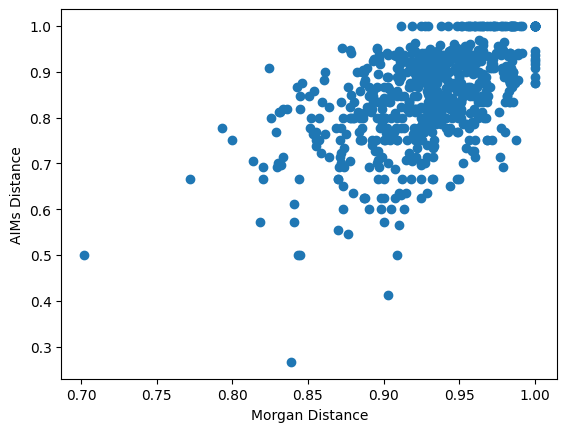

In [123]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import numpy as np

def printPlots(print1, print2, print1_name, print2_name):
    plt.scatter(print1, print2)
    m,b = np.polyfit(print1, print2, deg = 1)
    print(r2_score(print2, m*np.array(print1)+b))
    plt.xlabel(f'{print1_name} Distance')
    plt.ylabel(f'{print2_name} Distance')
    plt.show()
    return

printPlots(mor_dist, aims_dist, 'Morgan', 'AIMs' )

0.30395067031321354


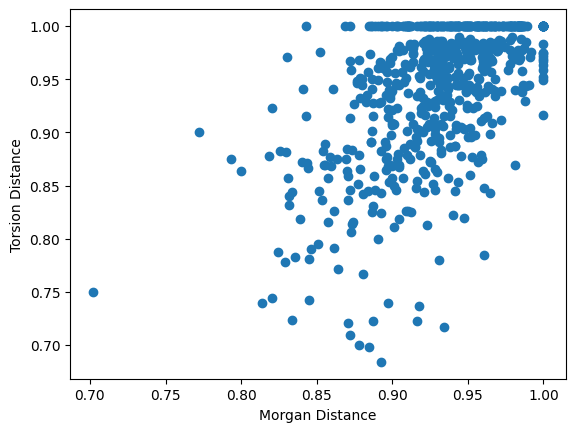

In [124]:
printPlots(mor_dist, tor_dist, "Morgan", "Torsion")

0.2360507263639101


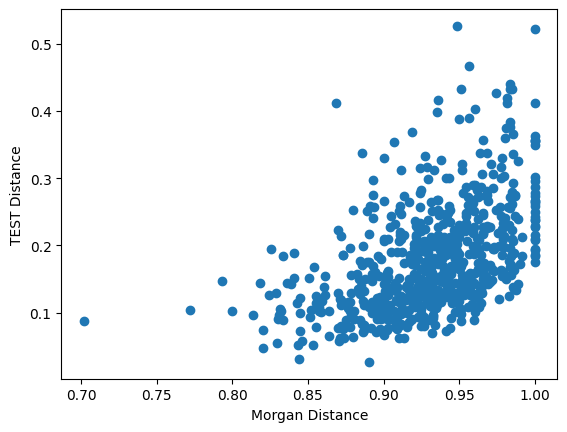

In [125]:
printPlots(mor_dist, test_dist, 'Morgan', 'TEST')

0.36325468751780055


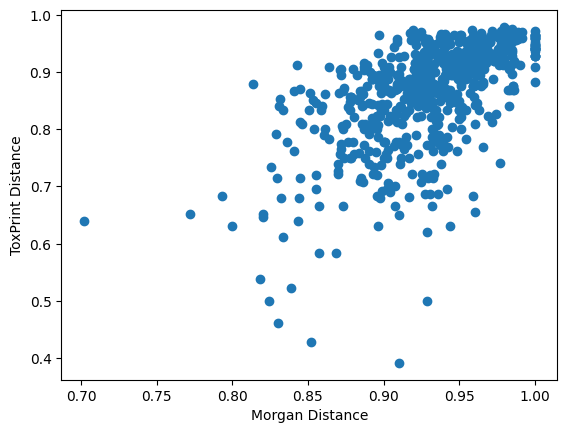

In [126]:
printPlots(mor_dist, tp_dist, 'Morgan', 'ToxPrint')

0.0663978390865142


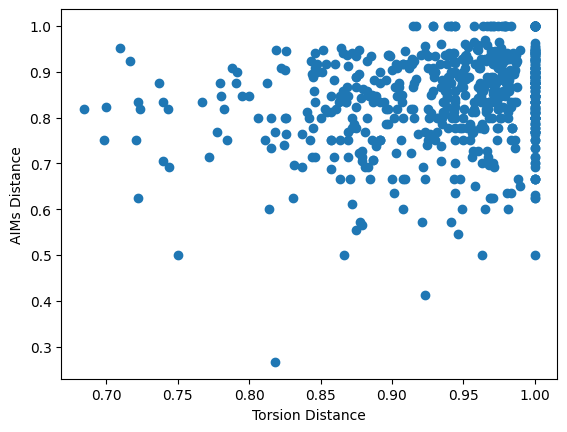

In [127]:
printPlots(tor_dist, aims_dist, "Torsion", 'AIMs')

0.14401540495794385


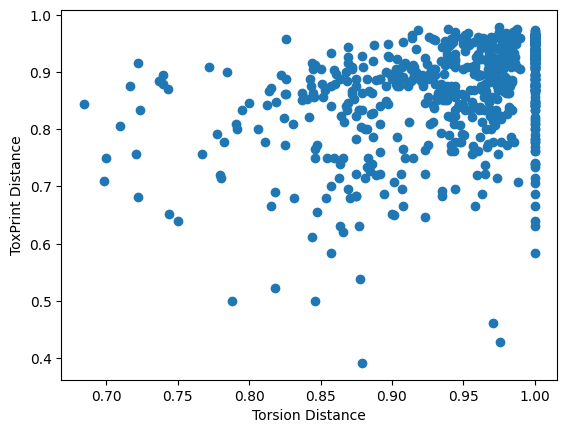

In [128]:
printPlots(tor_dist, tp_dist, "Torsion", 'ToxPrint')

0.19131129564856308


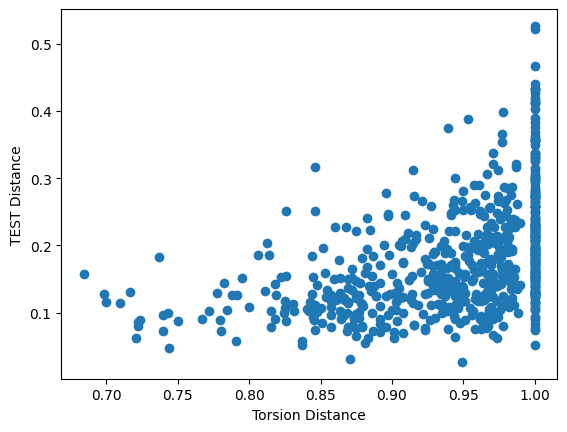

In [129]:
printPlots(tor_dist, test_dist, "Torsion", 'TEST')

0.22369292138800279


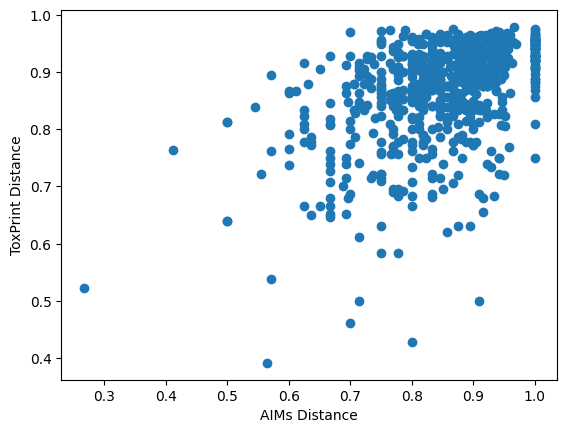

In [130]:
printPlots(aims_dist, tp_dist, "AIMs", 'ToxPrint')

0.16677994245625316


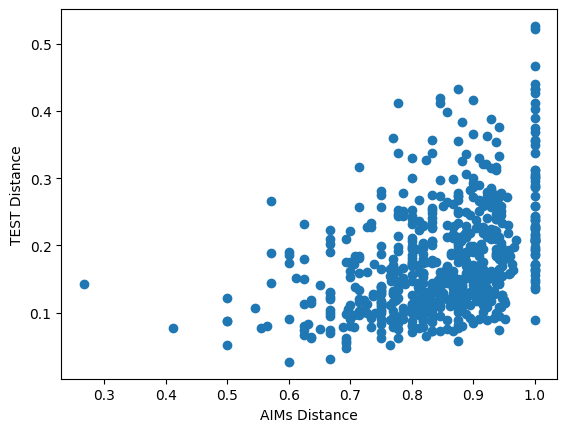

In [131]:
printPlots(aims_dist, test_dist, "AIMs", 'TEST')

0.12224758320175289


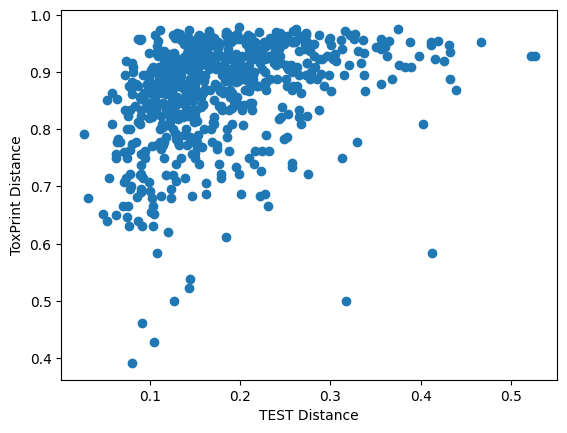

In [132]:
printPlots(test_dist, tp_dist, "TEST", 'ToxPrint')

# Fingeprint Stability

In [133]:
#Changeable code for importing results from the VM
print(f"scp aleary@v2626umcth031.rtord.epa.gov:/home/aleary/Grid-Search_Optimization/outputs/hazard/hazard_fingerprint_opt_sampling_part2.csv references/hazard/fingerprints/ ")

scp aleary@v2626umcth031.rtord.epa.gov:/home/aleary/Grid-Search_Optimization/outputs/hazard/hazard_fingerprint_opt_sampling_part2.csv references/hazard/fingerprints/ 


In [158]:
import pandas as pd

#Reading in results print-by-print
morgan_results = pd.read_csv('../references/hazard/fingerprints/hazard_fingerprint_morgan_sampling.csv')
morgan_results = pd.concat([morgan_results, pd.read_csv('../references/hazard/fingerprints/hazard_fingerprint_morgan_sampling_part2.csv')])
morgan_results = morgan_results.set_index('chems')

opt_results = pd.read_csv('../references/hazard/fingerprints/hazard_fingerprint_opt_sampling_part2.csv')
opt_results = opt_results.set_index('chems')


In [159]:
#Set the main endpoint for dependent code, import the necessary DataFrame
main_endpoint = "hazard"
hazard = ' Acute Mammalian Toxicity Oral'
main_endpoint = main_endpoint + hazard.replace(' ', '_')
import pandas as pd
data = pd.read_csv(f"../src/data/{main_endpoint}_pre-grid-search.csv").set_index('dsstox_sid')
data.head()

,score,listType,tp_fp0,tp_fp1,tp_fp2,tp_fp3,tp_fp4,tp_fp5,tp_fp6,tp_fp7,...,N-CH=N-OH [oxime-type] correction,Ring rx: -OH ortho to -C=N-N-carbon,=C-(C#N)-C#N [dicyano] correction,Aromatic nitrogen-C-C(=S)-N struct corr.,Cyclic ketoxime(>C=N-OH) [1 olefin attach],C=N-O-sulfur(aliphatic) [iminoxy] correc,-S-N(-C(=O)-C)-C(=O)-C struct correction,-Sulfur(+4) charged halide-type,Ring rx: S=P(O)(O)O- / 5-mem (2 nitrogen).1,O=P(-O)(-O)-C-OH correction
dsstox_sid,,,,,,,,,,,,,,,,,,,,,
DTXSID5020281,3,B,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DTXSID8020961,3,B,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DTXSID0021834,2,B,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DTXSID5024768,1,A,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DTXSID60883290,1,A,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [160]:
#Remove QSAR predictions for the sake of testing 
# (and now for comparing test results)
data = data.loc[data['listType'] != 'C']

In [161]:
from genra.rax.skl.hybrid import GenRAPredClassHybrid, GenRAPredValueHybrid
from sklearn.model_selection import train_test_split

slices = [slice(1,730),slice(730,2778), slice(2778,4826), slice(4826, None)]

#18,431
x_train, x_test, y_train, y_test = train_test_split(data.iloc[:, 2:], data.iloc[:, 0], stratify=data.iloc[:,0], random_state = 3751, test_size=0.5)
#9,215
x_train2, x_test2, y_train2, y_test2 = train_test_split(x_train, y_train, stratify=y_train, random_state = 3554, test_size=0.5)
#4,607
x_train3, x_test3, y_train3, y_test3 = train_test_split(x_train2, y_train2, stratify=y_train2, random_state = 5678, test_size=0.5)
#2,303
x_train4, x_test4, y_train4, y_test4 = train_test_split(x_train3, y_train3, stratify=y_train3, random_state = 8509, test_size=0.5)
#1,151
x_train5, x_test5, y_train5, y_test5 = train_test_split(x_train4, y_train4, stratify=y_train4, random_state = 821, test_size=0.5)
#575
x_train6, x_test6, y_train6, y_test6 = train_test_split(x_train5, y_train5, stratify=y_train5, random_state = 2359, test_size=0.5)

estimator = GenRAPredClassHybrid(slices = slices, metric = 'jaccard', hybrid_weights = [28,56,9,9], n_neighbors = 8)


In [162]:
x_tests = [x_test, x_test2, x_test3, x_test4, x_test5, x_test6]

In [163]:
#Add a column with actual y values for scoring
morgan_results['y'] = ''
morgan_results.loc[morgan_results['test_set']==1,'y'] = y_test2
morgan_results.loc[morgan_results['test_set']==0, 'y'] = y_test
morgan_results.loc[morgan_results['test_set']==2, 'y'] = y_test3
morgan_results.loc[morgan_results['test_set']==3, 'y'] = y_test4
morgan_results.loc[morgan_results['test_set']==4, 'y'] = y_test5
morgan_results.loc[morgan_results['test_set']==5, 'y'] = y_test6

In [164]:
opt_results['y'] = ''
opt_results.loc[opt_results['test_set']==1,'y'] = y_test2
opt_results.loc[opt_results['test_set']==0, 'y'] = y_test
opt_results.loc[opt_results['test_set']==2, 'y'] = y_test3
opt_results.loc[opt_results['test_set']==3, 'y'] = y_test4
opt_results.loc[opt_results['test_set']==4, 'y'] = y_test5
opt_results.loc[opt_results['test_set']==5, 'y'] = y_test6

In [165]:
morgan_results['y'] = morgan_results['y'].astype('int')
opt_results['y'] = opt_results['y'].astype('int')

In [166]:
from sklearn.metrics import balanced_accuracy_score
print('Morgan results (bal_acc)')
print(f'Set 0: {balanced_accuracy_score(morgan_results.loc[morgan_results['test_set'] == 0, 'y'], morgan_results.loc[morgan_results['test_set'] == 0,'class_preds'])}')
print(f'Set 1: {balanced_accuracy_score(morgan_results.loc[morgan_results['test_set'] == 1, 'y'], morgan_results.loc[morgan_results['test_set'] == 1,'class_preds'])}')
print(f'Set 2: {balanced_accuracy_score(morgan_results.loc[morgan_results['test_set'] == 2, 'y'], morgan_results.loc[morgan_results['test_set'] == 2,'class_preds'])}')
print(f'Set 3: {balanced_accuracy_score(morgan_results.loc[morgan_results['test_set'] == 3, 'y'], morgan_results.loc[morgan_results['test_set'] == 3,'class_preds'])}')
print(f'Set 4: {balanced_accuracy_score(morgan_results.loc[morgan_results['test_set'] == 4, 'y'], morgan_results.loc[morgan_results['test_set'] == 4,'class_preds'])}')
print(f'Set 5: {balanced_accuracy_score(morgan_results.loc[morgan_results['test_set'] == 5, 'y'], morgan_results.loc[morgan_results['test_set'] == 5,'class_preds'])}')

Morgan results (bal_acc)
Set 0: 0.4859450425331907
Set 1: 0.4292071894009829
Set 2: 0.38553361928351854
Set 3: 0.3570982559694607
Set 4: 0.3530256872455394
Set 5: 0.3249936932801383


In [167]:
print('Optimum results (bal_acc)')
print(f'Set 0: {balanced_accuracy_score(opt_results.loc[opt_results['test_set'] == 0, 'y'], opt_results.loc[opt_results['test_set'] == 0,'class_preds'])}')
print(f'Set 1: {balanced_accuracy_score(opt_results.loc[opt_results['test_set'] == 1, 'y'], opt_results.loc[opt_results['test_set'] == 1,'class_preds'])}')
print(f'Set 2: {balanced_accuracy_score(opt_results.loc[opt_results['test_set'] == 2, 'y'], opt_results.loc[opt_results['test_set'] == 2,'class_preds'])}')
print(f'Set 3: {balanced_accuracy_score(opt_results.loc[opt_results['test_set'] == 3, 'y'], opt_results.loc[opt_results['test_set'] == 3,'class_preds'])}')
print(f'Set 4: {balanced_accuracy_score(opt_results.loc[opt_results['test_set'] == 4, 'y'], opt_results.loc[opt_results['test_set'] == 4,'class_preds'])}')
print(f'Set 5: {balanced_accuracy_score(opt_results.loc[opt_results['test_set'] == 5, 'y'], opt_results.loc[opt_results['test_set'] == 5,'class_preds'])}')

Optimum results (bal_acc)
Set 0: 0.5118929264389759
Set 1: 0.45269290949345875
Set 2: 0.4044016379570924
Set 3: 0.3713675834355758
Set 4: 0.3499569276076953
Set 5: 0.3432458501192516


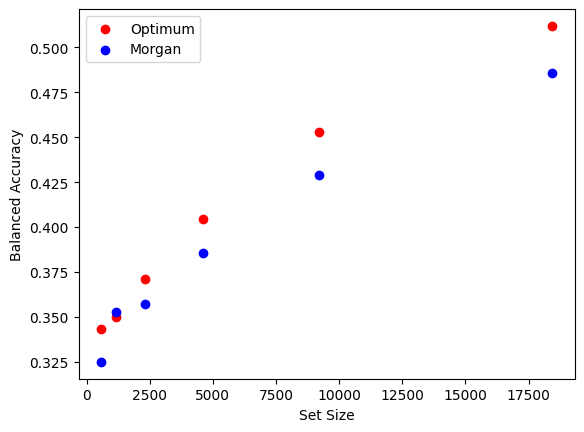

In [168]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

size_list = [len(x_test), len(x_test2), len(x_test3), len(x_test4), len(x_test5), len(x_test6)]

for i in range(1):
    plt.scatter(size_list[i], balanced_accuracy_score(opt_results.loc[opt_results['test_set'] == i, 'y'], opt_results.loc[opt_results['test_set'] == i,'class_preds']), color = 'red', label = 'Optimum')
    plt.scatter(size_list[i], balanced_accuracy_score(morgan_results.loc[morgan_results['test_set'] == i, 'y'], morgan_results.loc[morgan_results['test_set'] == i,'class_preds']), color = 'blue', label = 'Morgan')
for i in range(1,6):
    plt.scatter(size_list[i], balanced_accuracy_score(opt_results.loc[opt_results['test_set'] == i, 'y'], opt_results.loc[opt_results['test_set'] == i,'class_preds']), color = 'red')
    plt.scatter(size_list[i], balanced_accuracy_score(morgan_results.loc[morgan_results['test_set'] == i, 'y'], morgan_results.loc[morgan_results['test_set'] == i,'class_preds']), color = 'blue')

plt.legend()
plt.xlabel('Set Size')
plt.ylabel('Balanced Accuracy')
plt.show()

In [169]:
from sklearn.metrics import confusion_matrix

print(f'Set 0: \n{confusion_matrix(morgan_results.loc[morgan_results['test_set'] == 0, 'y'], morgan_results.loc[morgan_results['test_set'] == 0,'class_preds'])}')
print(f'Set 1: \n{confusion_matrix(morgan_results.loc[morgan_results['test_set'] == 1, 'y'], morgan_results.loc[morgan_results['test_set'] == 1,'class_preds'])}')
print(f'Set 2: \n{confusion_matrix(morgan_results.loc[morgan_results['test_set'] == 2, 'y'], morgan_results.loc[morgan_results['test_set'] == 2,'class_preds'])}')
print(f'Set 3: \n{confusion_matrix(morgan_results.loc[morgan_results['test_set'] == 3, 'y'], morgan_results.loc[morgan_results['test_set'] == 3,'class_preds'])}')
print(f'Set 4: \n{confusion_matrix(morgan_results.loc[morgan_results['test_set'] == 4, 'y'], morgan_results.loc[morgan_results['test_set'] == 4,'class_preds'])}')
print(f'Set 5: \n{confusion_matrix(morgan_results.loc[morgan_results['test_set'] == 5, 'y'], morgan_results.loc[morgan_results['test_set'] == 5,'class_preds'])}')

Set 0: 
[[1791 1852   85   25]
 [1161 9042  379   62]
 [ 189 1788  804  160]
 [ 101  435  182  376]]
Set 1: 
[[ 746 1081   38   12]
 [ 552 4550  181   39]
 [ 108 1008  285   69]
 [  43  259   97  148]]
Set 2: 
[[ 331  584   15    8]
 [ 308 2289   50   14]
 [  72  533   97   33]
 [  21  166   33   54]]
Set 3: 
[[ 122  333   10    4]
 [ 103 1182   37    9]
 [  27  281   49   11]
 [  12   77   27   20]]
Set 4: 
[[ 56 176   3   0]
 [ 70 575  14   6]
 [ 12 149  19   4]
 [  4  46   4  14]]
Set 5: 
[[ 22  93   1   1]
 [ 37 280  15   1]
 [  9  77   6   0]
 [  2  22   3   7]]


In [170]:
unclean_morgan = morgan_results.copy()

clean_proba = []
for w in morgan_results['class_proba']:
    cleaner_list = []
    for x in w.split(' '):
        word = ''
        for y in x:
            if y in ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '.']:
                word = word + y
        if len(word) > 0:
            cleaner_list.append(float(word))
    clean_proba.append(cleaner_list)

# Attach the cleaned lists created above
for i in range(4):
    morgan_results[f'class_proba{i}'] = [clean_proba[j][i] for j in range(len(clean_proba))]

#Drop the original proba columns
morgan_results = morgan_results.drop(columns = {'class_proba'})

In [171]:
unclean_opt = opt_results.copy()

clean_proba = []
for w in opt_results['class_proba']:
    cleaner_list = []
    for x in w.split(' '):
        word = ''
        for y in x:
            if y in ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '.']:
                word = word + y
        if len(word) > 0:
            cleaner_list.append(float(word))
    clean_proba.append(cleaner_list)

# Attach the cleaned lists created above
for i in range(4):
    opt_results[f'class_proba{i}'] = [clean_proba[j][i] for j in range(len(clean_proba))]

#Drop the original proba columns
opt_results = opt_results.drop(columns = {'class_proba'})

In [172]:
from sklearn.metrics import roc_auc_score
import numpy as np

# Attach the cleaned lists created above
clean_proba = {}
print("Morgan ROC AUC")
for test_set in range(6):
    clean_proba[test_set] = []
    for w in unclean_morgan.loc[morgan_results['test_set']==test_set,'class_proba']:
        cleaner_list = []
        for x in w.split(' '):
            word = ''
            for y in x:
                if y in ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '.']:
                    word = word + y
            if len(word) > 0:
                cleaner_list.append(float(word))
        clean_proba[test_set].append(cleaner_list)

for i in range(6):
    print(f"Set {i} ROC AUC: {roc_auc_score(y_true = morgan_results.loc[morgan_results['test_set'] == i, 'y'].values, y_score = np.array(clean_proba[i]), multi_class = 'ovo', average = 'weighted')}")

Morgan ROC AUC
Set 0 ROC AUC: 0.7788808675997348
Set 1 ROC AUC: 0.7402490315910306
Set 2 ROC AUC: 0.6956342806484216
Set 3 ROC AUC: 0.6723641250051894
Set 4 ROC AUC: 0.6707912544215112
Set 5 ROC AUC: 0.6445474139526738


In [173]:
from sklearn.metrics import roc_auc_score
import numpy as np

# Attach the cleaned lists created above
clean_opt_proba = {}
for test_set in range(6):
    clean_opt_proba[test_set] = []
    for w in unclean_opt.loc[opt_results['test_set']==test_set,'class_proba']:
        cleaner_list = []
        for x in w.split(' '):
            word = ''
            for y in x:
                if y in ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '.']:
                    word = word + y
            if len(word) > 0:
                cleaner_list.append(float(word))
        clean_opt_proba[test_set].append(cleaner_list)

for i in range(6):
    print(f"Set {i} ROC AUC: {roc_auc_score(y_true = opt_results.loc[opt_results['test_set'] == i, 'y'].values, y_score = np.array(clean_opt_proba[i]), multi_class = 'ovo', average = 'weighted')}")

Set 0 ROC AUC: 0.798397392782394
Set 1 ROC AUC: 0.7625891996506314
Set 2 ROC AUC: 0.7116829906672925
Set 3 ROC AUC: 0.6895384863829265
Set 4 ROC AUC: 0.6799413978361656
Set 5 ROC AUC: 0.6403226193025208


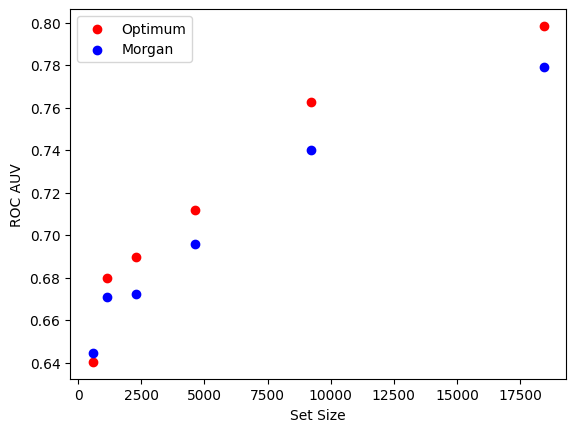

In [174]:
fig, ax = plt.subplots()

size_list = [len(x_test), len(x_test2), len(x_test3), len(x_test4), len(x_test5), len(x_test6)]

for i in range(1):
    plt.scatter(size_list[i], roc_auc_score(y_true = opt_results.loc[opt_results['test_set'] == i, 'y'].values, y_score = np.array(clean_opt_proba[i]), multi_class = 'ovo', average = 'weighted'), color = 'red', label = 'Optimum')
    plt.scatter(size_list[i], roc_auc_score(y_true = morgan_results.loc[morgan_results['test_set'] == i, 'y'].values, y_score = np.array(clean_proba[i]), multi_class = 'ovo', average = 'weighted'), color = 'blue', label = 'Morgan')
for i in range(1,6):
    plt.scatter(size_list[i], roc_auc_score(y_true = opt_results.loc[opt_results['test_set'] == i, 'y'].values, y_score = np.array(clean_opt_proba[i]), multi_class = 'ovo', average = 'weighted'), color = 'red')
    plt.scatter(size_list[i], roc_auc_score(y_true = morgan_results.loc[morgan_results['test_set'] == i, 'y'].values, y_score = np.array(clean_proba[i]), multi_class = 'ovo', average = 'weighted'), color = 'blue')
plt.legend()
plt.xlabel('Set Size')
plt.ylabel('ROC AUV')
plt.show()

# Hazard Test

In [2]:
import pandas as pd
tests = pd.read_csv('../references/hazard/fingerprints/fingerprint_stability15.csv')

In [3]:
tests = tests.drop(columns=['Unnamed: 0.2', 'Unnamed: 0', 'Unnamed: 0.1', 'Unnamed: 0.1.1',
       'Unnamed: 0.1.1.1', 'Unnamed: 0.1.1.1.1', 'Unnamed: 0.1.1.1.1.1',
       'Unnamed: 0.1.1.1.1.1.1', 'Unnamed: 0.1.1.1.1.1.1.1',
       'Unnamed: 0.1.1.1.1.1.1.1.1', 'Unnamed: 0.1.1.1.1.1.1.1.1.1',
       'Unnamed: 0.1.1.1.1.1.1.1.1.1.1', 'Unnamed: 0.1.1.1.1.1.1.1.1.1.1.1',
       'Unnamed: 0.1.1.1.1.1.1.1.1.1.1.1.1',
       'Unnamed: 0.1.1.1.1.1.1.1.1.1.1.1.1.1', 'mean_fit_time', 'std_fit_time',
       'mean_score_time', 'std_score_time', 'params'])

In [4]:
tests['morgan'] = ''
tests['toxprint'] = ''
tests['torsion'] = ''
tests['aims'] = ''
for i in range(len(tests)):
    param_list = tests['param_hybrid_weights'][i]
    pieces = param_list.split(',')
    tests.loc[i,'toxprint'] = int(pieces[0][1:])
    tests.loc[i,'morgan'] = int(pieces[1])
    tests.loc[i,'torsion'] = int(pieces[2])
    tests.loc[i,'aims'] = int(pieces[3][:-1])
tests = tests.drop(columns=['param_hybrid_weights'])

In [5]:
twenty_inc_mor = tests.loc[tests['morgan'] % 20 == 0]
twenty_inc_mor_tox = twenty_inc_mor.loc[twenty_inc_mor['toxprint'] % 20 == 0]
twenty_inc_mor_tox_tor = twenty_inc_mor_tox.loc[twenty_inc_mor_tox['torsion'] % 20 == 0]
twenty_inc = twenty_inc_mor_tox_tor[twenty_inc_mor_tox_tor['aims'] % 20 == 0]

In [7]:
twenty_inc

,split0_test_roc_auc_ovo_weighted,split1_test_roc_auc_ovo_weighted,split2_test_roc_auc_ovo_weighted,split3_test_roc_auc_ovo_weighted,split4_test_roc_auc_ovo_weighted,mean_test_roc_auc_ovo_weighted,std_test_roc_auc_ovo_weighted,rank_test_roc_auc_ovo_weighted,split0_test_balanced_accuracy,split1_test_balanced_accuracy,...,split4_test_balanced_accuracy,mean_test_balanced_accuracy,std_test_balanced_accuracy,rank_test_balanced_accuracy,state,n_size,morgan,toxprint,torsion,aims
0,0.571614,0.555891,0.562703,0.522716,0.559654,0.554515,0.016727,263,0.230114,0.261164,...,0.222844,0.255324,0.026439,273,8556,576,0,0,0,100
2,0.546837,0.534310,0.575393,0.531692,0.566866,0.551020,0.017409,277,0.236742,0.248953,...,0.244908,0.256588,0.025541,271,8556,576,0,0,20,80
4,0.547033,0.537415,0.598998,0.531874,0.553617,0.553788,0.023824,268,0.250947,0.265152,...,0.252046,0.264843,0.023869,213,8556,576,0,0,40,60
6,0.572208,0.570070,0.616649,0.624294,0.512606,0.579165,0.040007,44,0.259470,0.268939,...,0.245295,0.273762,0.023244,135,8556,576,0,0,60,40
8,0.613867,0.525153,0.621745,0.619138,0.552639,0.586508,0.039916,8,0.265152,0.266098,...,0.248702,0.274869,0.019280,119,8556,576,0,0,80,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31083,0.787606,0.784083,0.781740,0.773587,0.772393,0.779882,0.005941,37,0.489795,0.481721,...,0.480274,0.485998,0.004733,35,2791,18432,40,60,0,0
31084,0.780209,0.777392,0.780484,0.771622,0.771954,0.776332,0.003866,41,0.490334,0.485619,...,0.481167,0.484816,0.004982,39,2791,18432,0,80,0,20
31085,0.779194,0.778965,0.782886,0.770853,0.766830,0.775745,0.005944,42,0.494652,0.482387,...,0.480616,0.485348,0.005706,37,2791,18432,0,80,20,0
31086,0.778673,0.778103,0.778052,0.767209,0.766424,0.773692,0.005624,44,0.488379,0.481421,...,0.473905,0.481266,0.005983,44,2791,18432,20,80,0,0


In [8]:
twenty_inc['state'].unique()

array([8556, 3322, 2396, 8260,  896, 4236, 7868, 5977, 7308, 8180, 2135,
       4105, 2822, 6020, 2004, 9956, 9405, 1053, 1492, 2791], dtype=int64)

In [6]:
best_tests = pd.DataFrame()
averages = pd.DataFrame()
for size in twenty_inc['n_size'].unique():
    size_df = twenty_inc.loc[twenty_inc['n_size']== size]
    for state in twenty_inc['state'].unique():
        mini_df = size_df.loc[size_df['state']== state]
        best_test = mini_df.loc[mini_df['rank_test_roc_auc_ovo_weighted'] == mini_df['rank_test_roc_auc_ovo_weighted'].min()]
        best_test = best_test[['state', 'n_size','mean_test_roc_auc_ovo_weighted', 'morgan', 'toxprint', 'torsion', 'aims']]
        best_tests = pd.concat([best_test,best_tests])
        ten_best_tests = mini_df.sort_values('rank_test_roc_auc_ovo_weighted', ascending = True).iloc[:5]
        ten_best_avg = ten_best_tests[['morgan', 'toxprint', 'torsion', 'aims']].mean()
        ten_best_avg['state'] = state
        ten_best_avg['n_size'] = size
        averages = pd.concat([pd.DataFrame(ten_best_avg), averages], axis = 1)
averages = averages.transpose().reset_index(drop = True)

In [7]:
worst_tests = pd.DataFrame()
averages = pd.DataFrame()
for size in twenty_inc['n_size'].unique():
    size_df = twenty_inc.loc[twenty_inc['n_size']== size]
    for state in twenty_inc['state'].unique():
        mini_df = size_df.loc[size_df['state']== state]
        worst_test = mini_df.loc[mini_df['rank_test_roc_auc_ovo_weighted'] == mini_df['rank_test_roc_auc_ovo_weighted'].max()]
        worst_test = worst_test[['state', 'n_size','mean_test_roc_auc_ovo_weighted', 'morgan', 'toxprint', 'torsion', 'aims']]
        worst_tests = pd.concat([worst_test,worst_tests])

In [10]:
averages.groupby('n_size').mean()

,morgan,toxprint,torsion,aims,state
n_size,,,,,
576,24.6,28.8,27.8,18.8,4939.1
1152,29.4,28.2,21.8,20.6,4939.1
2304,32.4,28.4,20.0,19.2,4939.1
4608,31.8,27.4,19.2,21.6,4939.1
9216,31.6,27.4,18.4,22.6,4939.1
18432,31.789474,29.052632,17.894737,21.263158,4939.1


In [19]:
averages.groupby('n_size').std()

,morgan,toxprint,torsion,aims,state
n_size,,,,,
576,15.425202,17.392073,13.137331,15.846633,3037.8373
1152,10.323198,14.125751,11.927853,11.699753,3037.8373
2304,15.513661,13.417977,12.379950,10.102631,3037.8373
4608,10.660305,6.900801,9.934522,6.540562,3037.8373
9216,9.258851,3.952348,7.611625,5.072112,3037.8373
18432,6.596118,3.487656,5.714453,3.280280,3037.8373


In [20]:
best_tests.groupby('n_size').mean()

,state,mean_test_roc_auc_ovo_weighted,morgan,toxprint,torsion,aims
n_size,,,,,,
576,4939.100000,0.634460,26.0,27.0,30.0,17.0
1152,4939.100000,0.655375,34.0,26.0,22.0,18.0
2304,4939.100000,0.688442,39.0,26.0,16.0,19.0
4608,4805.571429,0.719472,33.333333,29.52381,16.190476,20.952381
9216,4862.095238,0.753268,39.047619,22.857143,17.142857,20.952381
18432,5112.884615,0.786538,31.538462,31.538462,16.923077,20.0


In [21]:
best_tests.groupby('n_size').std()

,state,mean_test_roc_auc_ovo_weighted,morgan,toxprint,torsion,aims
n_size,,,,,,
576,3037.837300,0.023907,28.358606,21.788457,22.004784,17.501880
1152,3037.837300,0.016827,23.485718,20.621910,18.238190,15.761379
2304,3037.837300,0.010631,26.337885,16.026294,16.670175,12.096106
4608,3023.484770,0.007316,20.330601,10.235326,16.271506,7.684245
9216,2981.871407,0.003641,13.380868,7.171372,9.561829,4.364358
18432,2965.398069,0.002588,20.531402,10.076629,12.253728,0.000000


In [22]:
best_tests.groupby(['n_size','morgan', 'toxprint', 'torsion', 'aims']).count().tail(20)

state  mean_test_roc_auc_ovo_weighted
n_size morgan toxprint torsion aims                                       
2304   80     20       0       0         1                               1
4608   0      20       60      20        1                               1
              40       20      40        1                               1
                       40      20        1                               1
       20     20       40      20        1                               1
              40       0       40        1                               1
                       20      20        4                               4
       40     20       20      20        4                               4
              40       0       20        2                               2
                       20      0         1                               1
       60     20       0       20        5                               5
9216   20     20       20      40        1                               1
                       40      20        1                               1
              40       20      20        3                               3
       40     20       20      20       12                              12
       60     20       0       20        4                               4
18432  0      40       40      20        3                               3
       20     40       20      20       12                              12
       40     20       20      20        4                               4
       60     20       0       20        7                               7

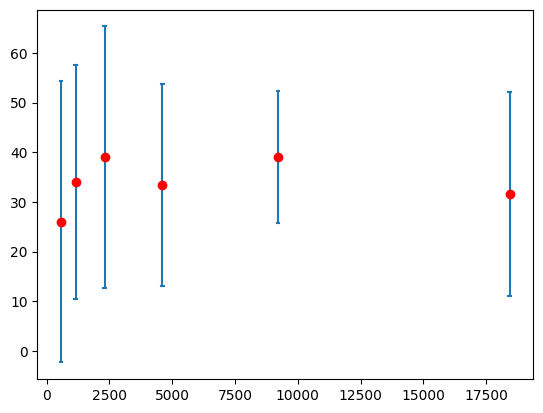

In [44]:
import matplotlib.pyplot as plt
averaged_set = best_tests.groupby('n_size').mean()
std_set = best_tests.groupby('n_size').std()

for i in range(len(best_tests.groupby('n_size').mean())):
    horizontal_line_width = 100
    color = 'tab:blue'
    x = averaged_set.index[i]
    mean = averaged_set.iloc[i].loc['morgan']
    interval = std_set.iloc[i].loc['morgan']
    left = x - horizontal_line_width / 2
    top = mean - interval
    right = x + horizontal_line_width / 2
    bottom = mean + interval
    plt.plot([x, x], [top, bottom], color=color)
    plt.plot([left, right], [top, top], color=color)
    plt.plot([left, right], [bottom, bottom], color=color)
    plt.plot(x, mean, 'o', color = 'red')

plt.show()

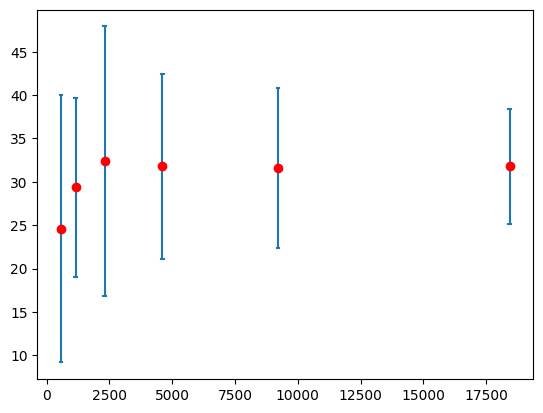

In [45]:
import matplotlib.pyplot as plt
averaged_set = averages.groupby('n_size').mean()
std_set = averages.groupby('n_size').std()
for i in range(len(averages.groupby('n_size').mean())):
    horizontal_line_width = 100
    color = 'tab:blue'
    x = averaged_set.index[i]
    mean = averaged_set.iloc[i].loc['morgan']
    interval = std_set.iloc[i].loc['morgan']
    left = x - horizontal_line_width / 2
    top = mean - interval
    right = x + horizontal_line_width / 2
    bottom = mean + interval
    plt.plot([x, x], [top, bottom], color=color)
    plt.plot([left, right], [top, top], color=color)
    plt.plot([left, right], [bottom, bottom], color=color)
    plt.plot(x, mean, 'o', color = 'red')
plt.show()

# Combined Tests

Uses code from "Updated Tests"

In [45]:
import pandas as pd
data = pd.read_csv(f"../src/data/LD50_pre-grid-search_and_TEST.csv")

In [46]:
from sklearn.metrics import pairwise_distances
import numpy as np

slices = [slice(0,729),slice(729,2777), slice(2777,4825), slice(4825, 5727), slice(5727, None)]

tp_dist_matrix = pairwise_distances(np.array(data.iloc[:,slices[0]]), np.array(data.iloc[:,slices[0]]), metric = 'jaccard')
mor_dist_matrix = pairwise_distances(np.array(data.iloc[:,slices[1]]), np.array(data.iloc[:,slices[1]]), metric = 'jaccard')
tor_dist_matrix = pairwise_distances(np.array(data.iloc[:,slices[2]]), np.array(data.iloc[:,slices[2]]), metric = 'jaccard')
aim_dist_matrix = pairwise_distances(np.array(data.iloc[:,slices[3]]), np.array(data.iloc[:,slices[3]]), metric = 'jaccard')
test_dist_matrix = pairwise_distances(np.array(data.iloc[:,slices[4]]), np.array(data.iloc[:,slices[4]]), metric = 'jaccard')

c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybrid\venv\Lib\site-packages\sklearn\metrics\pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybrid\venv\Lib\site-packages\sklearn\metrics\pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybrid\venv\Lib\site-packages\sklearn\metrics\pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybr

In [47]:
best_tests = best_tests.reset_index(drop=True)
dist_matrices = {}
for i in range(len(best_tests)):
    a = best_tests.loc[i, 'morgan']
    b = best_tests.loc[i,'toxprint']
    c = best_tests.loc[i,'torsion']
    d = best_tests.loc[i,'aims']
    distances = (b*tp_dist_matrix+a*mor_dist_matrix+c*tor_dist_matrix+d*aim_dist_matrix)/100
    dist_matrices[f'[{b},{a},{c},{d}]'] = distances

In [48]:
worst_tests = worst_tests.reset_index(drop=True)
bad_list = []
for i in range(len(worst_tests)):
    a = worst_tests.loc[i, 'morgan']
    b = worst_tests.loc[i,'toxprint']
    c = worst_tests.loc[i,'torsion']
    d = worst_tests.loc[i,'aims']
    distances = (b*tp_dist_matrix+a*mor_dist_matrix+c*tor_dist_matrix+d*aim_dist_matrix)/100
    dist_matrices[f'[{b},{a},{c},{d}]'] = distances
    bad_list.append(f'[{b},{a},{c},{d}]')

In [49]:

mor_coords = []
plottable_mor_points = pd.DataFrame(mor_dist_matrix)

plottable_points = {}
all_coords = {}
for key in dist_matrices.keys():
    plottable_points[key] = pd.DataFrame(dist_matrices[key])
    all_coords[key] = []
for i in range(5830):
    for j in range(5830):
        if i<j:
            mor_coords.append(plottable_mor_points.iloc[i,j])
pd.DataFrame(mor_coords).to_csv(f'../references/hazard/fingerprints/combined_tests/morgan_coords.csv')



# for key in list(dist_matrices.keys())[23:]:
#     for i in range(5830):
#         for j in range(5830):
#             if i<j:
#                 all_coords[key].append(plottable_points[key].iloc[i,j])
#     pd.DataFrame(all_coords[key]).to_csv(f'../references/hazard/fingerprints/combined_tests/{key}.csv')    


# plottable_points2 = {}
# for key in dist_matrices2.keys():
#     plottable_points2[key] = pd.DataFrame(dist_matrices2[key])
#     all_coords[key] = []
# for key in list(dist_matrices2.keys()):
#     for i in range(5830):
#         for j in range(5830):
#             if i<j:
#                 all_coords[key].append(plottable_points2[key].iloc[i,j])
#     pd.DataFrame(all_coords[key]).to_csv(f'../references/hazard/fingerprints/combined_tests/{key}.csv')        



In [15]:
key

'[40,60,0,0]'

In [17]:
list(dist_matrices.keys())

['[20,40,20,20]',
 '[40,0,40,20]',
 '[40,20,20,20]',
 '[20,60,0,20]',
 '[40,0,20,40]',
 '[20,20,40,20]',
 '[40,20,0,40]',
 '[40,40,0,20]',
 '[20,0,60,20]',
 '[40,40,20,0]',
 '[20,20,20,40]',
 '[20,80,0,0]',
 '[20,0,40,40]',
 '[20,60,20,0]',
 '[0,80,0,20]',
 '[60,20,0,20]',
 '[20,40,0,40]',
 '[60,40,0,0]',
 '[20,40,40,0]',
 '[0,60,0,40]',
 '[40,20,40,0]',
 '[0,40,40,20]',
 '[0,0,60,40]',
 '[40,60,0,0]',
 '[0,60,20,20]',
 '[60,0,20,20]',
 '[40,0,60,0]',
 '[80,0,20,0]',
 '[60,20,20,0]',
 '[60,0,0,40]',
 '[20,20,60,0]',
 '[0,20,60,20]',
 '[0,0,100,0]',
 '[0,0,0,100]',
 '[0,60,40,0]',
 '[0,20,80,0]',
 '[0,100,0,0]',
 '[0,40,0,60]',
 '[100,0,0,0]',
 '[0,20,0,80]',
 '[0,0,80,20]',
 '[0,40,60,0]',
 '[80,0,0,20]']

In [50]:
indices = {}
for low, high in [(k,k+0.1) for k in np.arange(0,1.1,0.1)]:
    indices[f'[{round(low,1)},{round(high,1)})'] = []
    for i in range(len(mor_coords)):
        if mor_coords[i]< high and mor_coords[i] >= low:
            indices[f'[{round(low,1)},{round(high,1)})'].append(i)

In [51]:
import random

test_indices = []
for key in indices.keys():
    rand_list = [random.randint(0, len(indices[key])-1) for _ in range(108)]
    for j in rand_list:
        test_indices.append(indices[key][j])


In [52]:

mor_test_values = [mor_coords[x] for x in test_indices]

test_sets = {}
for key in dist_matrices.keys():
    key_coords = list(pd.read_csv(f'../references/hazard/fingerprints/combined_tests/{key}.csv').set_index('Unnamed: 0').values.reshape(1,-1)[0])  
    key_tests = [key_coords[x] for x in test_indices]
    test_sets[key] = key_tests


In [37]:
# test_sets2 = {}
# for key in dist_matrices2.keys():
#     key_coords = list(pd.read_csv(f'../references/hazard/fingerprints/combined_tests/{key}.csv').set_index('Unnamed: 0').values.reshape(1,-1)[0])  
#     key_tests = [key_coords[x] for x in test_indices]
#     test_sets[key] = key_tests

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import numpy as np

def printR2(print1, print2):
    m,b = np.polyfit(print1, print2, deg = 1)
    r2 = r2_score(print2, m*np.array(print1)+b)
    return r2

In [ ]:
paired_test_distances = {}
list_of_keys = []
for key in dist_matrices:
    paired_test_distances[key] = []
    list_of_keys.append(key)
    for key2 in dist_matrices:
        paired_test_distances[key].append(printR2(test_sets[key], test_sets[key2]))

all_matchups = pd.DataFrame(paired_test_distances, index = list_of_keys)

In [17]:
# paired_test_distances2 = {}
# list_of_keys2 = []
# for key in dist_matrices2:
#     paired_test_distances2[key] = []
#     list_of_keys2.append(key)
#     for key2 in dist_matrices2:
#         paired_test_distances2[key].append(printR2(test_sets[key], test_sets[key2]))

# all_matchups2 = pd.DataFrame(paired_test_distances2, index = list_of_keys2)

In [ ]:

weight_list = []
for x, data in best_tests.iterrows():
    print = f'[{data['toxprint']},{data['morgan']},{data['torsion']},{data['aims']}]'
    weight_list.append(print)
best_tests['hybrid_weights'] = weight_list



results = {'size':[], 'max':[], 'min':[]}
for size in best_tests['n_size'].unique():
    tests = best_tests.loc[best_tests['n_size']==size]
    # tests2 = worst_tests.loc[worst_tests['n_size']==size]
    unique_values = tests['hybrid_weights'].unique()
    # unique_values2 = tests2['hybrid_weights'].unique()
    spreads = []
    for value1 in unique_values:
        for value2 in unique_values:
            spreads.append(all_matchups.loc[value1, value2])
    # for value1 in unique_values2:
    #     for value2 in unique_values2:
    #         spreads.append(all_matchups2.loc[value1, value2])
    results['size'].append(size)
    results['min'].append(min(spreads))
    results['max'].append(max([x for x in spreads if x < 1]))



In [19]:
pd.DataFrame(results)

,size,max,min
0,18432,0.994396,0.962049
1,4608,0.994835,0.938709
2,9216,0.994415,0.977142
3,2304,0.994415,0.923630
4,1152,0.994527,0.921876
5,576,0.994674,0.871365


In [ ]:
weight_list = []
for x, data in worst_tests.iterrows():
    print = f'[{data['toxprint']},{data['morgan']},{data['torsion']},{data['aims']}]'
    weight_list.append(print)
worst_tests['hybrid_weights'] = weight_list

results = {'size':[], 'max':[], 'min':[]}
for size in worst_tests['n_size'].unique():
    # tests = best_tests.loc[best_tests['n_size']==size]
    tests2 = worst_tests.loc[worst_tests['n_size']==size]
    # unique_values = tests['hybrid_weights'].unique()
    unique_values2 = tests2['hybrid_weights'].unique()
    spreads = []
    # for value1 in unique_values:
    #     for value2 in unique_values:
    #         spreads.append(all_matchups.loc[value1, value2])
    for value1 in unique_values2:
        for value2 in unique_values2:
            spreads.append(all_matchups.loc[value1, value2])
    results['size'].append(size)
    results['min'].append(min(spreads))
    results['max'].append(max([x for x in spreads if x < 1]))

In [ ]:
unique_values2

NameError: name 'unique_values2' is not defined

In [26]:
pd.DataFrame(results)

,size,max,min
0,18432,0.740894,0.740894
1,4608,0.740894,0.740894
2,9216,0.740894,0.740894
3,2304,0.995697,0.740894
4,1152,0.995697,0.740894
5,576,0.995697,0.740894


In [38]:
results = {'size':[], 'max':[], 'min':[], 'minweight1':[], 'minweight2':[], 'maxweight1':[], 'maxweight2':[]}
for size in worst_tests['n_size'].unique():
    tests = best_tests.loc[best_tests['n_size']==size]
    tests2 = worst_tests.loc[worst_tests['n_size']==size]
    unique_values = tests['hybrid_weights'].unique()
    unique_values2 = tests2['hybrid_weights'].unique()
    spreads = []
    value1s = []
    value2s = []
    for value1 in unique_values2:
        for value2 in unique_values:
            spreads.append(all_matchups.loc[value1, value2])
            value1s.append(value1)
            value2s.append(value2)
    results['size'].append(size)
    results['min'].append(min(spreads))
    results['max'].append(max([x for x in spreads if x < 1]))
    results['minweight1'].append(value1s[spreads.index(min(spreads))])
    results['minweight2'].append(value2s[spreads.index(min(spreads))])
    results['maxweight1'].append(value1s[spreads.index(max([x for x in spreads if x < 1]))])
    results['maxweight2'].append(value2s[spreads.index(max([x for x in spreads if x < 1]))])

In [39]:
pd.DataFrame(results)

,size,max,min,minweight1,minweight2,maxweight1,maxweight2
0,18432,0.926500,0.874402,"[0,0,100,0]","[20,60,0,20]","[0,0,100,0]","[40,0,40,20]"
1,4608,0.967515,0.827428,"[0,0,100,0]","[40,20,0,40]","[0,0,100,0]","[20,0,60,20]"
2,9216,0.947398,0.874402,"[0,0,100,0]","[20,60,0,20]","[0,0,0,100]","[20,20,20,40]"
3,2304,0.991687,0.828944,"[0,0,100,0]","[60,20,0,20]","[0,100,0,0]","[20,80,0,0]"
4,1152,0.992114,0.828944,"[0,0,100,0]","[60,20,0,20]","[0,40,0,60]","[0,60,0,40]"
5,576,0.992224,0.792025,"[0,0,100,0]","[60,0,0,40]","[0,40,60,0]","[20,20,60,0]"


In [34]:
best_tests.iloc[:,[1,-4,-3,-2,-1]].loc[best_tests['n_size']==18432]

from sklearn.metrics import pairwise_distances

df_dict = {'size':[], 
           'best':[], 'worst':[]}
for size in best_tests['n_size'].unique():
    max_best = pairwise_distances(best_tests.iloc[:,-4:].loc[best_tests['n_size']==size], metric='euclidean').max()
    max_worst = pairwise_distances(worst_tests.iloc[:,-4:].loc[worst_tests['n_size']==size], metric='euclidean').max()
    df_dict['size'].append(size)
    df_dict['best'].append(max_best)
    df_dict['worst'].append(max_worst)

pd.DataFrame(df_dict)


,size,best,worst
0,18432,74.833148,141.421356
1,4608,84.852814,141.421356
2,9216,56.568542,141.421356
3,2304,97.979590,141.421356
4,1152,109.544512,141.421356
5,576,116.619038,141.421356


In [41]:
top_bottom = pd.concat([best_tests, worst_tests])
df_dict = {'size':[], 
           'mix':[]}
for size in best_tests['n_size'].unique():
    max_mid = pd.DataFrame(pairwise_distances(top_bottom.iloc[:,-4:].loc[top_bottom['n_size']==size], metric='euclidean')).iloc[0:20,20:40].values.max()
    df_dict['size'].append(size)
    df_dict['mix'].append(max_mid)

pd.DataFrame(df_dict)

,size,mix
0,18432,120.000000
1,4608,120.000000
2,9216,120.000000
3,2304,129.614814
4,1152,129.614814
5,576,129.614814
